In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Data preparation

In [3]:
df = pd.read_csv("data\\Personality_Syncora_Synthetic.csv")

In [5]:
round(df.describe())

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
count,4998.0,4998.0,4998.0,4998.0,4998.0,4998.0,4998.0,4998.0
mean,4.0,0.0,4.0,3.0,0.0,6.0,4.0,0.0
std,3.0,0.0,3.0,2.0,0.0,4.0,3.0,0.0
min,-1.0,0.0,-1.0,-1.0,0.0,-1.0,-1.0,0.0
25%,2.0,0.0,2.0,1.0,0.0,3.0,1.0,0.0
50%,4.0,0.0,4.0,3.0,0.0,5.0,3.0,0.0
75%,7.0,1.0,6.0,5.0,1.0,10.0,6.0,1.0
max,12.0,1.0,11.0,8.0,1.0,16.0,11.0,1.0


- 'Time_spent_Alone': from -1 to 12,
-  'Stage_fear': boolean, 
- 'Social_event_attendance': -1 to 11,
- 'Going_outside': from -1 to 8, 
- 'Drained_after_socializing': boolean, 
- 'Friends_circle_size': -1 to 16,
- 'Post_frequency': -1 to 11, 
- 'Personality': boolean

In [7]:
df.columns = df.columns.str.lower()

In [8]:
df.columns

Index(['time_spent_alone', 'stage_fear', 'social_event_attendance',
       'going_outside', 'drained_after_socializing', 'friends_circle_size',
       'post_frequency', 'personality'],
      dtype='object')

## Exploratory Data Analysis (EDA)

In [33]:
print(f"Extroverts: {(df['personality'] == 0).sum()}\nIntroverts: {(df['personality'] == 1).sum()}")

Extroverts: 2597
Introverts: 2401


In [18]:
df[(df==-1)].sum()

time_spent_alone            -61.0
stage_fear                    0.0
social_event_attendance     -26.0
going_outside                -7.0
drained_after_socializing     0.0
friends_circle_size         -20.0
post_frequency              -39.0
personality                   0.0
dtype: float64

In [25]:
print(f'Missing values: {df.isnull().sum()}')

Missing values: time_spent_alone             0
stage_fear                   0
social_event_attendance      0
going_outside                0
drained_after_socializing    0
friends_circle_size          0
post_frequency               0
personality                  0
dtype: int64


In [ ]:
print(f'\nUnique values count per column: \n{df.nunique()}')
print(f'\nNumber of negative value: \n{(df<0).sum()}') # errors? 


Unique values count per column: 
time_spent_alone             14
stage_fear                    2
social_event_attendance      13
going_outside                10
drained_after_socializing     2
friends_circle_size          18
post_frequency               13
personality                   2
dtype: int64

Number of negative value: 
time_spent_alone             61
stage_fear                    0
social_event_attendance      26
going_outside                 7
drained_after_socializing     0
friends_circle_size          20
post_frequency               39
personality                   0
dtype: int64


Distribution of all features:


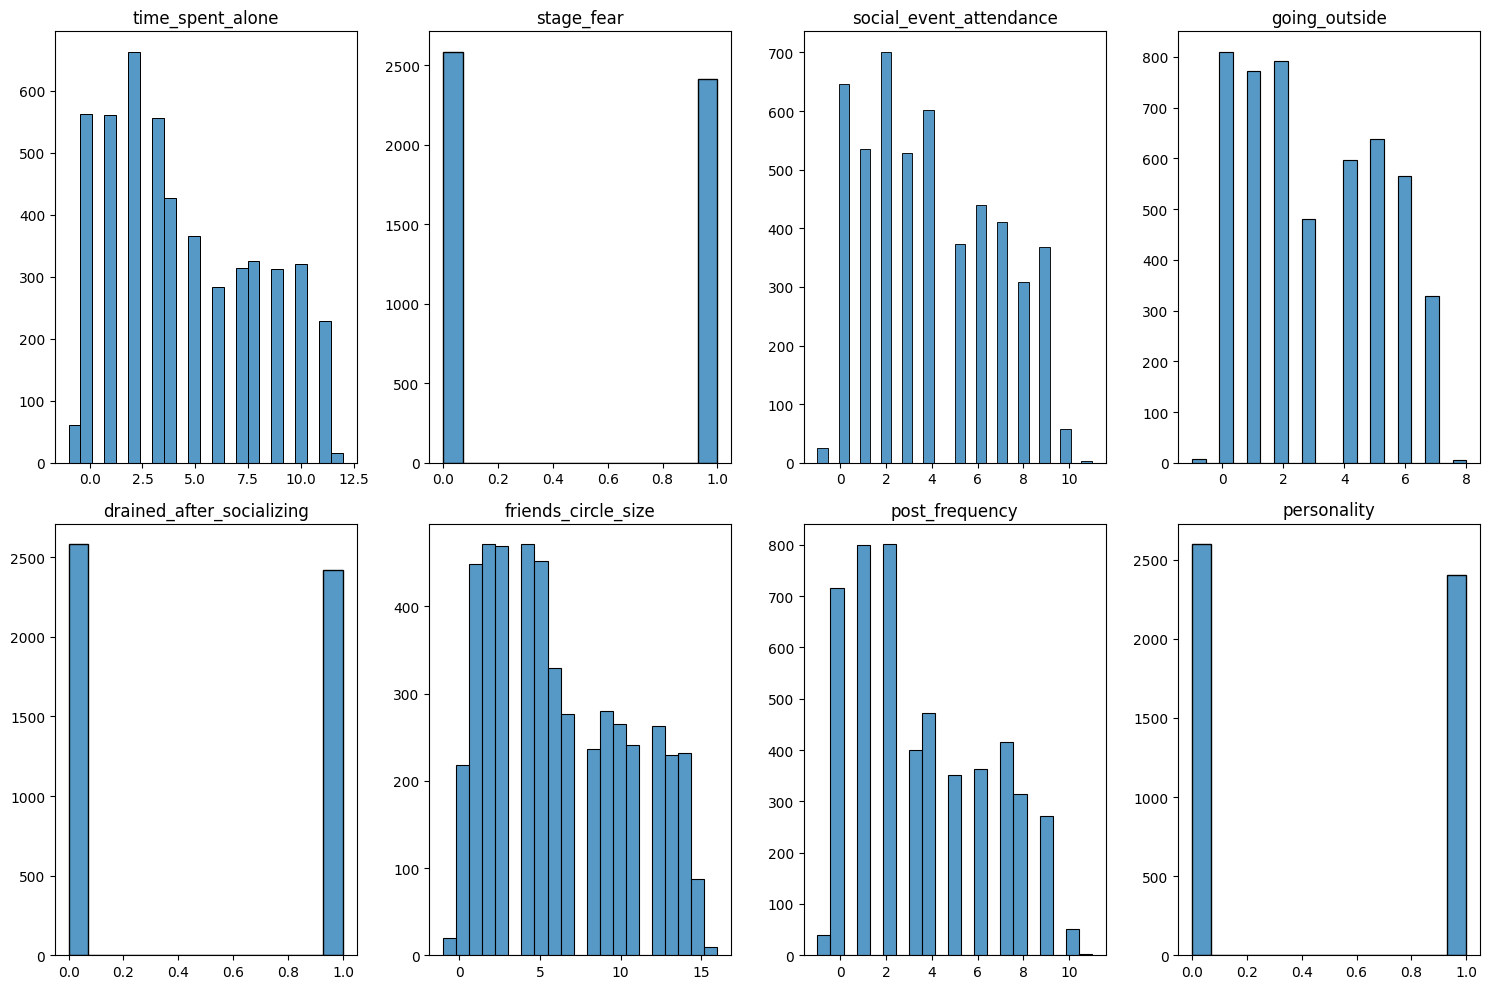

In [29]:
print("Distribution of all features:")
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(15, 10))
axes = axes.flatten()
features_to_plot =  df.columns.values
for i, col in enumerate(features_to_plot):
    sns.histplot(df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

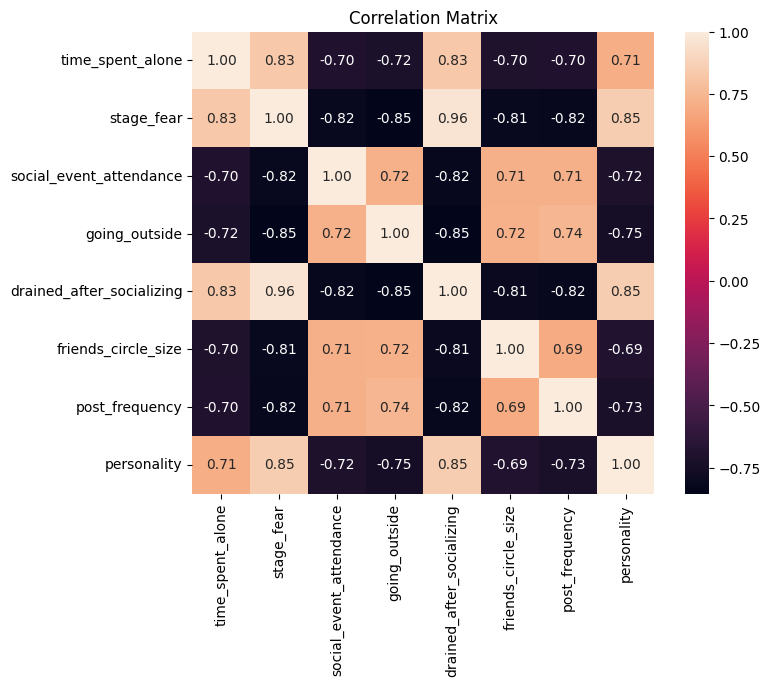

In [32]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", square=True)
plt.title("Correlation Matrix")
plt.show()

### Feature importance

In [37]:
global_mean = df.personality.mean()
print("Percentace of intorverted personality: ", round(global_mean, 2))

Percentace of intorverted personality:  0.48


In [38]:
df.columns

Index(['time_spent_alone', 'stage_fear', 'social_event_attendance',
       'going_outside', 'drained_after_socializing', 'friends_circle_size',
       'post_frequency', 'personality'],
      dtype='object')

In [ ]:
df_introvert = df[df['personality']==1]
df_extrovert = df[df['personality']==0]

In [ ]:
numerical_features = ['time_spent_alone', 'social_event_attendance','going_outside','friends_circle_size','post_frequency']

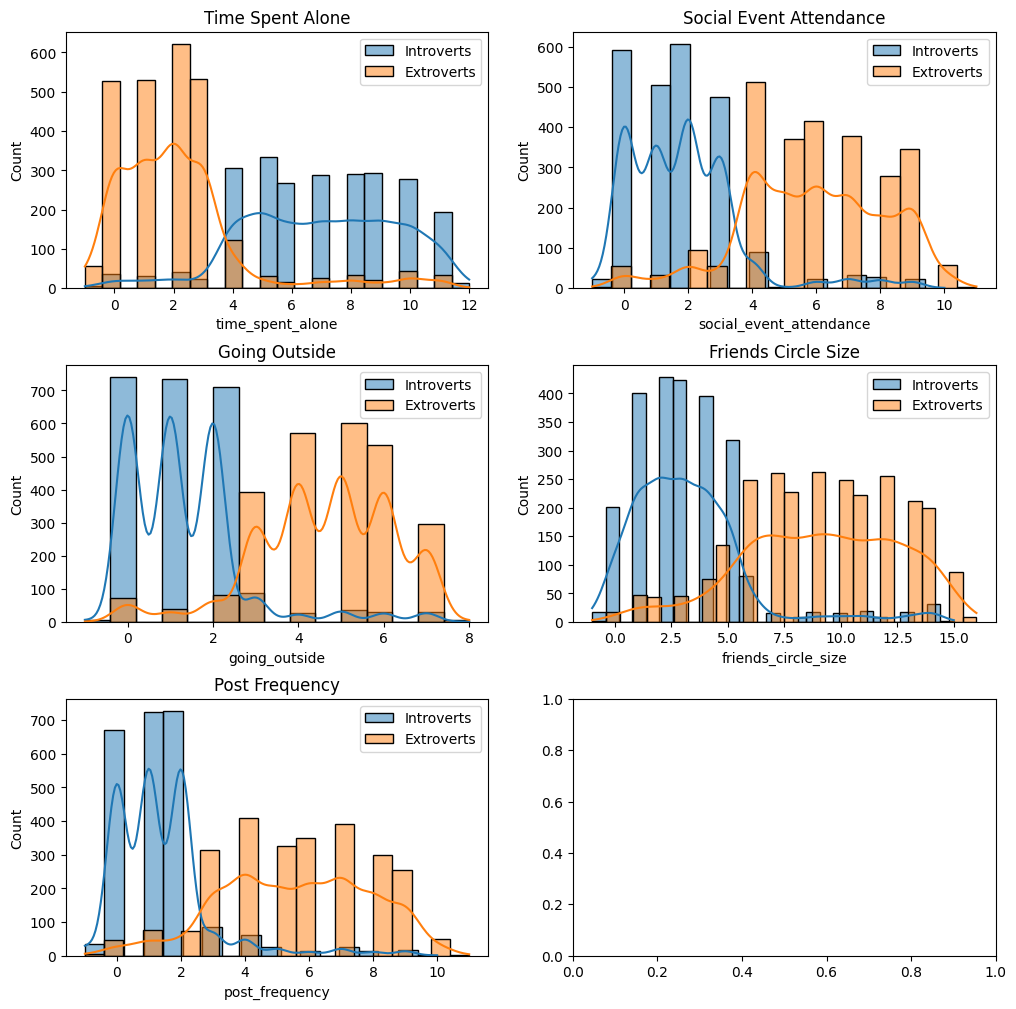

In [63]:
fig, axes = plt.subplots(3, 2, figsize=(12, 4 * 3))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    ax = axes[i]
    sns.histplot(df_introvert[feature], binwidth=0.6, kde=True, label='Introverts', ax=ax)
    sns.histplot(df_extrovert[feature], binwidth=0.6, kde=True, label='Extroverts', ax=ax)
    
    ax.set_title(feature.replace('_', ' ').title())
    ax.set_xlabel(feature)
    ax.legend()

fig.subplots_adjust(hspace=0.3)  # increase vertical spacing
plt.show()

In [64]:
df[df['stage_fear']==1].personality.mean()

np.float64(0.920049710024855)

In [65]:
df[df['drained_after_socializing']==1].personality.mean()

np.float64(0.9201489449731072)

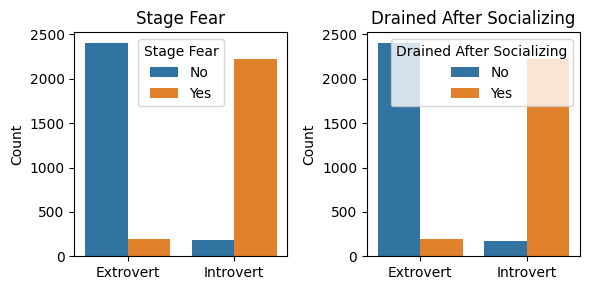

In [ ]:
bool_features = ['stage_fear', 'drained_after_socializing']
fig, axes = plt.subplots(1, len(bool_features), figsize=(6, 3))
df_personality = df.copy()
df_personality['personality_label'] = df['personality'].map({1: 'Introvert', 0: 'Extrovert'})
for i, feature in enumerate(bool_features):
    ax = axes[i]
    sns.countplot(
        data=df_personality,
        x='personality_label',
        hue=feature,
        ax=ax
    )
    ax.set_title(feature.replace('_', ' ').title())
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.legend(title=feature.replace('_', ' ').title(), labels=['No', 'Yes'])
    
plt.tight_layout()
plt.show()


In [96]:
from sklearn.metrics import mutual_info_score

def mutual_info_personality(series):
    return mutual_info_score(series, df.personality)

mi = df.apply(mutual_info_personality)
mi.sort_values(ascending=False)

personality                  0.692378
drained_after_socializing    0.428670
stage_fear                   0.427116
going_outside                0.419147
social_event_attendance      0.398757
post_frequency               0.396437
time_spent_alone             0.393771
friends_circle_size          0.358867
dtype: float64

### Data imputation
Some of the features have missing values recorde with -1. We will handle this by median imputation.

In [ ]:
df = df.replace(-1,np.nan)
df['time_spent_alone'].fillna(df['time_spent_alone'].median(), inplace=True)
df['social_event_attendance'].fillna(df['social_event_attendance'].median(), inplace=True)
df['going_outside'].fillna(df['going_outside'].median(), inplace=True)
df['friends_circle_size'].fillna(df['friends_circle_size'].median(), inplace=True)
df['post_frequency'].fillna(df['post_frequency'].median(), inplace=True)

## Model training and selection
- Logistic regrassion
- Desicion Tree
- Random Forest
- XGBoost

In [118]:
from sklearn.model_selection import train_test_split, KFold

In [91]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)
len(df_train), len(df_val), len(df_test)

(2998, 1000, 1000)

In [93]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [94]:
y_train = df_train.personality.values
y_val = df_val.personality.values
y_test = df_test.personality.values

del df_train['personality']
del df_val['personality']
del df_test['personality']

In [97]:
X_train = df_train.values
X_val = df_val.values
X_test = df_test.values

In [101]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X_train, y_train)
pd.DataFrame({"features": df_train.columns.values, "MI":mi})

,features,MI
0,time_spent_alone,0.384299
1,stage_fear,0.427724
2,social_event_attendance,0.406134
3,going_outside,0.421765
4,drained_after_socializing,0.433044
5,friends_circle_size,0.359178
6,post_frequency,0.397391


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

def plot_roc_auc(y_true, y_scores, label='Model'):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc_score = roc_auc_score(y_true, y_scores)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='blue', label=f'{label} (AUC = {auc_score:.3f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.show()

In [137]:
def train(X_train, y_train, model_class, hyperparams=None):
    if hyperparams is None:
        hyperparams = {}
    model = model_class(**hyperparams)
    model.fit(X_train, y_train)
    return model
    
def predict(X_val, model):
    y_pred = model.predict_proba(X_val)[:,1]
    return y_pred

In [131]:
def cross_fold_validation(df_full_train, model_class, hyperparams=None):
    kfold = KFold(n_splits = 5, shuffle=True, random_state=1)
    scores = []
    for train_idx, val_idx in kfold.split(df_full_train):
        df_train_kf = df_full_train.iloc[train_idx]
        df_val_kf = df_full_train.iloc[val_idx]
        y_train_kf = df_full_train['personality'].iloc[train_idx].values
        y_val_kf = df_full_train['personality'].iloc[val_idx].values
        
        X_train_kf = df_train_kf.drop(columns=['personality']).values
        X_val_kf = df_val_kf.drop(columns=['personality']).values
        
        model_kf = train(X_train_kf, y_train_kf, model_class, hyperparams)
        y_val_kf_pred = predict(X_val_kf, model_kf)
        score = roc_auc_score(y_val_kf, y_val_kf_pred)
        # print(f"AUROC score: {score}")
        scores.append(score)
    return scores


### Logistic Regression

In [102]:
from sklearn.linear_model import LogisticRegression
lg = LogisticRegression()
lg.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [109]:
dict(zip(df_train.columns.values,lg.coef_[0].round(3)))

{'time_spent_alone': np.float64(-0.036),
 'stage_fear': np.float64(2.358),
 'social_event_attendance': np.float64(-0.081),
 'going_outside': np.float64(-0.011),
 'drained_after_socializing': np.float64(2.694),
 'friends_circle_size': np.float64(0.076),
 'post_frequency': np.float64(-0.135)}

In [105]:
y_pred = lg.predict_proba(X_val)

In [107]:
y_pred_introvert = (y_pred[:,1] >= 0.5)

In [108]:
(y_pred_introvert == y_val).mean()

np.float64(0.93)

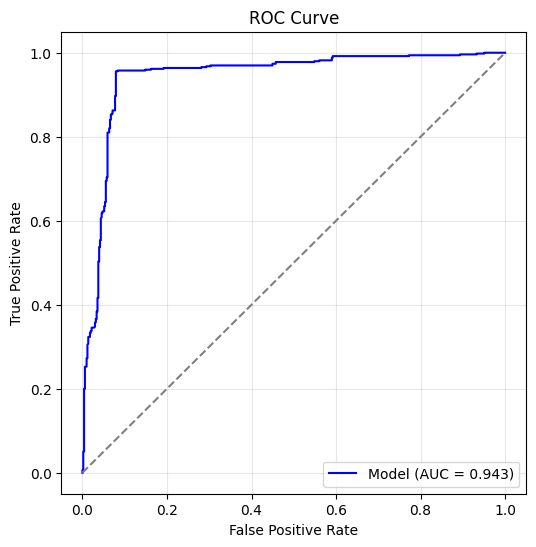

In [116]:
plot_roc_auc(y_val, y_pred[:,1])

#### Cross Validation

In [132]:
scores_logistic_regression = cross_fold_validation(df_full_train, LogisticRegression)   
print("AUC scores:", [round(s, 3) for s in scores_logistic_regression])
print("Mean AUC:", round(np.mean(scores_logistic_regression), 6))
print("Std AUC:", round(np.std(scores_logistic_regression), 3))

AUC scores: [0.946, 0.928, 0.948, 0.943, 0.949]
Mean AUC: 0.94295
Std AUC: 0.008


In [142]:
C = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
scores_c = {}
for c in C:
    scores = cross_fold_validation(df_full_train, model_class = LogisticRegression, hyperparams = {'C': c})
    scores_c[c] = scores

In [143]:
for c in scores_c.keys():
    print(c)
    scores = scores_c[c]
    print("Mean AUC:", round(np.mean(scores), 3))
    print("Std AUC:", round(np.std(scores), 3))

0.0001
Mean AUC: 0.915
Std AUC: 0.004
0.001
Mean AUC: 0.917
Std AUC: 0.005
0.01
Mean AUC: 0.922
Std AUC: 0.006
0.1
Mean AUC: 0.929
Std AUC: 0.007
1
Mean AUC: 0.943
Std AUC: 0.008
10
Mean AUC: 0.946
Std AUC: 0.008
100
Mean AUC: 0.946
Std AUC: 0.008
